In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class RobustCNN(nn.Module):
    def __init__(self, num_classes=2):
        super(RobustCNN, self).__init__()
        
        # Simpler, restricted feature maps! (16 -> 32 -> 64)
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16) 
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        
        self.fc1 = nn.Linear(64 * 28 * 28, 512)
        
        # Intense 50% Dropout 
        self.dropout = nn.Dropout(0.5) 
        
        self.fc2 = nn.Linear(512, num_classes)
        
    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        
        x = x.view(-1, 64 * 28 * 28) 
        
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

In [ ]:
import os
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split

class MHISTDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        self.label_map = {'HP': 0, 'SSA': 1}

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_name = os.path.join(self.img_dir, self.dataframe.iloc[idx]['Image Name'])
        image = Image.open(img_name).convert('RGB')
        label_str = self.dataframe.iloc[idx]['Majority Vote Label']
        label = self.label_map[label_str]
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

def get_dataloaders(csv_file='annotations.csv', img_dir='images', use_csv_partition=True, batch_size=32):
    df = pd.read_csv(csv_file)
    
    # #NEWUPDATED CODE: Separate transforms for train/test to apply data augmentation only to training
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=0.5),   # #NEWUPDATED CODE: Augmentation
        transforms.RandomVerticalFlip(p=0.5),     # #NEWUPDATED CODE: Augmentation
        transforms.RandomRotation(degrees=15),    # #NEWUPDATED CODE: Augmentation
        transforms.ToTensor(),         
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) 
    ])
    
    test_transform = transforms.Compose([
        transforms.Resize((224, 224)), 
        transforms.ToTensor(),         
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) 
    ])
    
    if use_csv_partition:
        print("Dataset Split: Using predefined CSV 'Partition'...")
        train_df = df[df['Partition'] == 'train']
        test_df = df[df['Partition'] == 'test']
    else:
        print("Dataset Split: Random 80/20 Stratified Split...")
        train_df, test_df = train_test_split(
            df, test_size=0.2, random_state=42, stratify=df['Majority Vote Label']
        )
        
    train_dataset = MHISTDataset(train_df, img_dir, transform=train_transform) # #NEWUPDATED CODE: Use train_transform
    test_dataset = MHISTDataset(test_df, img_dir, transform=test_transform)    # #NEWUPDATED CODE: Use test_transform
    
    # #NEWUPDATED CODE: Removed WeightedRandomSampler. Went back to pure Shuffle=True randomness!
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, test_loader, train_dataset, test_dataset

train_loader, test_loader, train_dataset, test_dataset = get_dataloaders(
    use_csv_partition=True, 
    batch_size=16
)

print(f"Training samples: {len(train_dataset)}")
print(f"Testing samples: {len(test_dataset)}")

Using compute device: mps
Starting Training for 20 Epochs...
Epoch [01/20] | LR: 0.00100 | Loss: 4.2781 | Train Acc: 51.26% | Test Acc: 54.35% --> 🌟 Saved Best Model!
Epoch [02/20] | LR: 0.00100 | Loss: 0.6960 | Train Acc: 56.97% | Test Acc: 62.64% --> 🌟 Saved Best Model!
Epoch [03/20] | LR: 0.00100 | Loss: 0.6930 | Train Acc: 60.28% | Test Acc: 59.57%
Epoch [04/20] | LR: 0.00100 | Loss: 0.6870 | Train Acc: 59.26% | Test Acc: 62.03%
Epoch [05/20] | LR: 0.00050 | Loss: 0.6861 | Train Acc: 57.84% | Test Acc: 60.08%
Epoch [06/20] | LR: 0.00050 | Loss: 0.6787 | Train Acc: 59.63% | Test Acc: 58.96%
Epoch [07/20] | LR: 0.00050 | Loss: 0.6706 | Train Acc: 60.46% | Test Acc: 61.11%
Epoch [08/20] | LR: 0.00050 | Loss: 0.6729 | Train Acc: 61.06% | Test Acc: 53.63%
Epoch [09/20] | LR: 0.00050 | Loss: 0.6636 | Train Acc: 56.28% | Test Acc: 50.97%
Epoch [10/20] | LR: 0.00025 | Loss: 0.6675 | Train Acc: 53.33% | Test Acc: 47.29%
Epoch [11/20] | LR: 0.00025 | Loss: 0.6544 | Train Acc: 56.78% | Test A

In [33]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

device = torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using compute device: {device}")

# We go back to RobustCNN here!
model = RobustCNN(num_classes=2).to(device)

# We keep the 2.5x penalty to force Recall on SSA
class_weights = torch.tensor([1.0, 2.5]).to(device) 
criterion = nn.CrossEntropyLoss(weight=class_weights)

# We brought back weight_decay=1e-4!
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4) 
# Faster decay schedule
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

num_epochs = 20
best_test_acc = 0.0

print(f"Starting Training for {num_epochs} Epochs...")
for epoch in range(num_epochs):

    # --- TRAINING PHASE ---
    model.train() 
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for i, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels) 
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        
    train_acc = 100 * correct_train / total_train
        
    # --- EVALUATION PHASE ---
    model.eval() 
    correct_test = 0
    total_test = 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()
            
    test_acc = 100 * correct_test / total_test
    
    scheduler.step()
    
    saved_msg = ""
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        torch.save(model.state_dict(), 'best_model.pth')
        saved_msg = " --> 🌟 Saved Best Model!"
    
    current_lr = scheduler.get_last_lr()[0]
    print(f"Epoch [{epoch+1:02d}/{num_epochs:02d}] "
          f"| LR: {current_lr:.5f} "
          f"| Loss: {running_loss/len(train_loader):.4f} "
          f"| Train Acc: {train_acc:.2f}% "
          f"| Test Acc: {test_acc:.2f}%{saved_msg}")

print(f"\nTraining Complete! The most robust model achieved a test accuracy of {best_test_acc:.2f}% and is saved as 'best_model.pth'")

Using compute device: mps
Starting Training for 20 Epochs...
Epoch [01/20] | LR: 0.00100 | Loss: 4.3423 | Train Acc: 51.91% | Test Acc: 51.18% --> 🌟 Saved Best Model!
Epoch [02/20] | LR: 0.00100 | Loss: 0.6894 | Train Acc: 55.82% | Test Acc: 58.85% --> 🌟 Saved Best Model!
Epoch [03/20] | LR: 0.00100 | Loss: 0.6865 | Train Acc: 59.40% | Test Acc: 51.18%
Epoch [04/20] | LR: 0.00100 | Loss: 0.6731 | Train Acc: 61.47% | Test Acc: 66.84% --> 🌟 Saved Best Model!
Epoch [05/20] | LR: 0.00050 | Loss: 0.6858 | Train Acc: 59.31% | Test Acc: 59.26%
Epoch [06/20] | LR: 0.00050 | Loss: 0.6764 | Train Acc: 57.20% | Test Acc: 51.69%
Epoch [07/20] | LR: 0.00050 | Loss: 0.6604 | Train Acc: 61.70% | Test Acc: 47.39%
Epoch [08/20] | LR: 0.00050 | Loss: 0.6687 | Train Acc: 53.43% | Test Acc: 60.70%
Epoch [09/20] | LR: 0.00050 | Loss: 0.6536 | Train Acc: 53.66% | Test Acc: 48.82%
Epoch [10/20] | LR: 0.00025 | Loss: 0.6565 | Train Acc: 54.71% | Test Acc: 65.61%
Epoch [11/20] | LR: 0.00025 | Loss: 0.6459 | Tr

Running inference on the test set...

--- Standard Metrics ---
Accuracy:  68.58%
Precision: 57.10% (When model predicts SSA, how often is it right?)
Recall:    59.17% (Out of all actual SSAs, how many did the model find?)


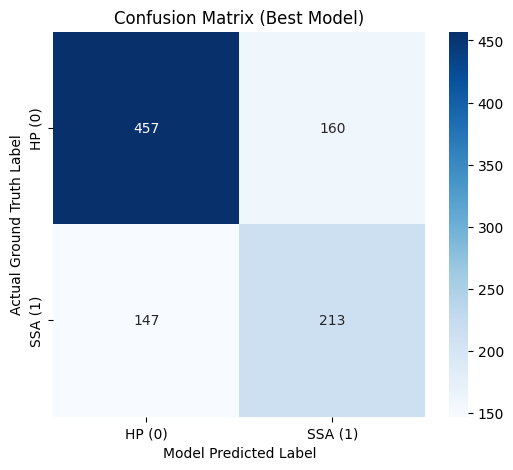


Running 100x Monte Carlo Bootstrap Validation...
--- Monte Carlo Results ---
Mean Accuracy: 68.32%
95% Confidence Interval: [65.19%, 70.94%]
Conclusion: We are 95% confident the true model accuracy lies within this boundary!


In [34]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, confusion_matrix, accuracy_score

# ==========================================
# 1. Load the Best Model
# ==========================================
# We have to initialize the architecture first, then load the weights into it
model = RobustCNN(num_classes=2).to(device)
model.load_state_dict(torch.load('best_model.pth', weights_only=True))

# CRITICAL: Put model in evaluation mode to disable Dropout and use learned BatchNorm stats
model.eval() 

# ==========================================
# 2. Collect Predictions over the Test Set
# ==========================================
all_preds = []
all_labels = []

print("Running inference on the test set...")
# No gradient needed for testing, saves memory!
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        
        # Get the class index with the highest probability
        _, predicted = torch.max(outputs.data, 1)
        
        # Move back to CPU and convert to standard numpy arrays for sklearn
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# ==========================================
# 3. Precision, Recall, and Confusion Matrix
# ==========================================
# In our map: HP = 0, SSA = 1. Sklearn defaults to calculating precision/recall for class 1
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
acc = accuracy_score(all_labels, all_preds)

print(f"\n--- Standard Metrics ---")
print(f"Accuracy:  {acc*100:.2f}%")
print(f"Precision: {precision*100:.2f}% (When model predicts SSA, how often is it right?)")
print(f"Recall:    {recall*100:.2f}% (Out of all actual SSAs, how many did the model find?)")

# Plot Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['HP (0)', 'SSA (1)'], 
            yticklabels=['HP (0)', 'SSA (1)'])
plt.ylabel('Actual Ground Truth Label')
plt.xlabel('Model Predicted Label')
plt.title('Confusion Matrix (Best Model)')
plt.show()

# ==========================================
# 4. Monte Carlo Bootstrap Validation (100x)
# ==========================================
print("\nRunning 100x Monte Carlo Bootstrap Validation...")
mc_accuracies = []
n_samples = len(all_labels)

for i in range(100):
    # Randomly sample indices with replacement
    indices = np.random.choice(n_samples, size=n_samples, replace=True)
    sample_preds = all_preds[indices]
    sample_labels = all_labels[indices]
    
    # Calculate accuracy for this random sample
    sample_acc = accuracy_score(sample_labels, sample_preds)
    mc_accuracies.append(sample_acc)

# Calculate 95% confidence intervals
mean_acc = np.mean(mc_accuracies)
lower_bound = np.percentile(mc_accuracies, 2.5)
upper_bound = np.percentile(mc_accuracies, 97.5)

print(f"--- Monte Carlo Results ---")
print(f"Mean Accuracy: {mean_acc*100:.2f}%")
print(f"95% Confidence Interval: [{lower_bound*100:.2f}%, {upper_bound*100:.2f}%]")
print(f"Conclusion: We are 95% confident the true model accuracy lies within this boundary!")


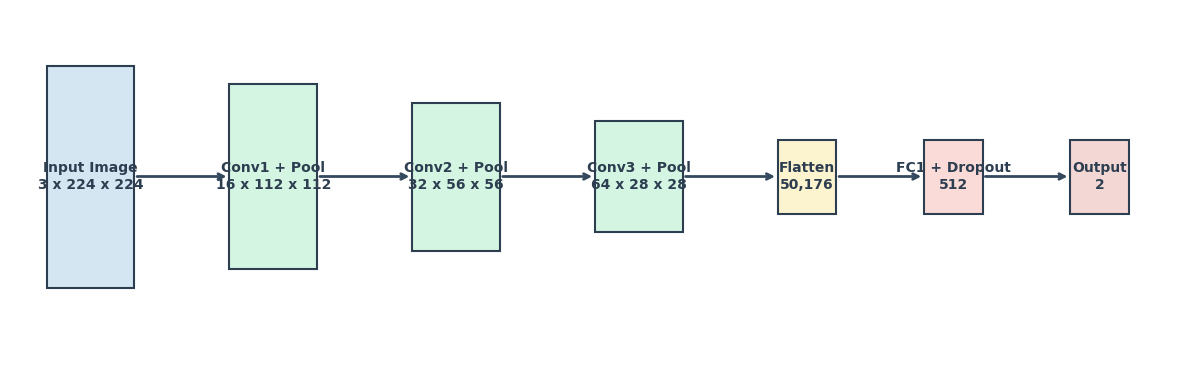

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(12, 4))

# Define the network blocks
# Format: (x_pos, y_pos, width, height, label, color)
blocks = [
    (0.0, 0.25, 1.2, 0.6, "Input Image\n3 x 224 x 224", "#d4e6f1"),
    (2.5, 0.30, 1.2, 0.5, "Conv1 + Pool\n16 x 112 x 112", "#d5f5e3"),
    (5.0, 0.35, 1.2, 0.4, "Conv2 + Pool\n32 x 56 x 56", "#d5f5e3"),
    (7.5, 0.40, 1.2, 0.3, "Conv3 + Pool\n64 x 28 x 28", "#d5f5e3"),
    (10.0, 0.45, 0.8, 0.2, "Flatten\n50,176", "#fcf3cf"),
    (12.0, 0.45, 0.8, 0.2, "FC1 + Dropout\n512", "#fadbd8"),
    (14.0, 0.45, 0.8, 0.2, "Output\n2", "#f2d7d5")
]

# Draw the blocks
for (x, y, w, h, label, color) in blocks:
    rect = patches.Rectangle((x, y), w, h, linewidth=1.5, edgecolor='#2c3e50', facecolor=color)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, label, ha='center', va='center', fontsize=10, fontweight='bold', color='#2c3e50')

# Draw the connecting arrows
for i in range(len(blocks)-1):
    x1 = blocks[i][0] + blocks[i][2]
    y1 = blocks[i][1] + blocks[i][3]/2
    x2 = blocks[i+1][0]
    y2 = blocks[i+1][1] + blocks[i+1][3]/2
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1), 
                arrowprops=dict(arrowstyle="->", lw=2, color='#34495e'))

# Format the plot area
ax.set_xlim(-0.5, 15.5)
ax.set_ylim(0, 1)
ax.axis('off')

# Save as a high-quality PDF for LaTeX
plt.tight_layout()
plt.savefig('cnn_architecture.pdf', format='pdf', bbox_inches='tight')
plt.show()


In [4]:
from torchinfo import summary

model = RobustCNN(num_classes=2)
model.load_state_dict(torch.load("best_model.pth", map_location="cpu"))

summary(model, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
RobustCNN                                [1, 2]                    --
├─Conv2d: 1-1                            [1, 16, 224, 224]         448
├─BatchNorm2d: 1-2                       [1, 16, 224, 224]         32
├─MaxPool2d: 1-3                         [1, 16, 112, 112]         --
├─Conv2d: 1-4                            [1, 32, 112, 112]         4,640
├─BatchNorm2d: 1-5                       [1, 32, 112, 112]         64
├─MaxPool2d: 1-6                         [1, 32, 56, 56]           --
├─Conv2d: 1-7                            [1, 64, 56, 56]           18,496
├─BatchNorm2d: 1-8                       [1, 64, 56, 56]           128
├─MaxPool2d: 1-9                         [1, 64, 28, 28]           --
├─Linear: 1-10                           [1, 512]                  25,690,624
├─Dropout: 1-11                          [1, 512]                  --
├─Linear: 1-12                           [1, 2]                    1

In [1]:
import os
print(os.getcwd())

/Users/ythacker/Documents/Classes/Computer Vision/Final Project
